# 11 — Strategy Lab: a head-to-head arena with honest findings

**Phase 1 portfolio artifact.** This notebook is a self-contained *research memo*:
it loads the demo lake, runs three systematic strategies across three transaction-cost
regimes against an equal-weight buy-and-hold benchmark, and records evidence-backed
**FindingCards** — **including negative results**.

> A defensible negative is a stronger portfolio line than a cherry-picked Sharpe.

**Status:** the lake holds *synthetic* data by default (`make demo`), so the verdicts
below are intentionally sobering — a geometric random walk carries no exploitable
signal by construction. Re-run `equity demo seed --real` for market data and every
card regenerates identically. Leakage-free purged walk-forward CV and an
XGBoost/LightGBM model comparison land in **Phase 2**.

## §0 Setup

Run with the backtesting engine group (and `viz` for plots):

```bash
uv sync --group backtesting --group viz
uv run jupyter lab notebooks/11-strategy-lab.ipynb
```

Plots degrade gracefully to a printed note if the `viz` group is absent.

In [1]:
import sys
from datetime import date
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import duckdb
import polars as pl

from equity_lake.core.logging import setup_structured_logging
setup_structured_logging(level="ERROR")  # keep the memo readable; surface only real errors

from equity_lake.backtesting.arena import run_arena
from equity_lake.backtesting.report import drawdown_series, write_arena_artifacts
from equity_lake.core.config import TickerConfig
from equity_lake.core.paths import US_EQUITY_DIR
from equity_lake.findings.writer import load_finding_cards
from equity_lake.storage.lake_reader import duckdb_scan_for

pl.Config(fmt_str_lengths=50, tbl_cols=8)

## §1 Hypothesis

Three falsifiable claims, each becoming a `FindingCard` with a `positive` /
`negative` / `inconclusive` verdict:

1. **Strategy** — at least one systematic rule (momentum / mean-reversion / trend)
   beats an equal-weight buy-and-hold benchmark on risk-adjusted return.
2. **Cost** — realistic transaction costs (≈14.3 bps fee + 30 bps tax) materially
   degrade Sharpe versus a zero-cost backtest.
3. **Benchmark** — no passive equal-weight benchmark should lose to a tuned rule
   after costs.

In [2]:
HYPOTHESES = {
    "strategy": "a systematic rule beats equal-weight buy-and-hold on Sharpe",
    "cost": "realistic costs materially degrade Sharpe vs zero-cost",
    "benchmark": "no equal-weight benchmark should lose to a rule after costs",
}
HYPOTHESES

{'strategy': 'a systematic rule beats equal-weight buy-and-hold on Sharpe',
 'cost': 'realistic costs materially degrade Sharpe vs zero-cost',
 'benchmark': 'no equal-weight benchmark should lose to a rule after costs'}

## §2 Data

Universe = the first eight `demo`-group tickers (kept small for readable equity
curves; the arena generalises to the full 50). Coverage is read straight off the
Delta-partitioned bronze lake with DuckDB.

In [3]:
universe = TickerConfig().get_tickers_by_group("demo")[:8]
START, END = date(2022, 1, 3), date(2026, 8, 4)
print("universe:", universe)

con = duckdb.connect()
con.execute("INSTALL delta; LOAD delta;")
scan = duckdb_scan_for(US_EQUITY_DIR)
con.execute(
    f"SELECT min(date) AS first_day, max(date) AS last_day, "
    f"count(distinct ticker) AS tickers, count(*) AS rows FROM {scan}"
).fetchdf()

universe: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'BRK-B']


,first_day,last_day,tickers,rows
0,2021-08-05,2026-08-04,50,65200


## §3 Method

`run_arena()` loads the window once and runs every **strategy × cost-regime**
combination on the *same* data, then attaches an equal-weight buy-and-hold
benchmark. One failing run is logged and skipped rather than aborting the arena.

- **Strategies** — `momentum` (cross-sectional), `mean_reversion` (Bollinger),
  `trend_following` (SMA 50/200 crossover).
- **Cost regimes** — `zero`, `realistic` (14.3 bps fee + 30 bps tax), `high` (50 bps).
- **Benchmark** — equal-weight buy-and-hold of the same universe.

**Honesty note:** this is a full-window pseudo-OOS. Signal construction uses only
information available up to each bar (no lookahead), but there is no purged
embargoed walk-forward split yet — that ML rigor is Phase 2.

In [4]:
outcome = run_arena(universe, START, END, initial_cash=100_000.0)
strategies = sorted({r.strategy for r in outcome.runs})
regimes = sorted({r.cost_regime for r in outcome.runs})
print(f"{len(outcome.runs)} runs: strategies={strategies} regimes={regimes}")

9 runs: strategies=['mean_reversion', 'momentum', 'trend_following'] regimes=['high', 'realistic', 'zero']


## §4 Results

Risk-adjusted ranking across the 3×3 grid:

In [5]:
rows = []
for run in outcome.runs:
    res = run.result
    rows.append({
        "strategy": run.strategy,
        "cost_regime": run.cost_regime,
        "total_return": round(res.total_return, 4),
        "sharpe": round(res.sharpe_ratio, 3),
        "max_drawdown": round(res.max_drawdown, 4),
    })
pl.DataFrame(rows).sort("sharpe", descending=True)

strategy,cost_regime,total_return,sharpe,max_drawdown
str,str,f64,f64,f64
"""momentum""","""zero""",0.0,0.0,0.0
"""momentum""","""realistic""",0.0,0.0,0.0
"""momentum""","""high""",0.0,0.0,0.0
"""mean_reversion""","""zero""",0.0136,-0.245,-0.1175
"""trend_following""","""zero""",-0.0451,-0.67,-0.0991
"""trend_following""","""realistic""",-0.1704,-1.389,-0.1776
"""mean_reversion""","""realistic""",-0.2627,-1.593,-0.3168
"""trend_following""","""high""",-0.3018,-2.105,-0.3018
"""mean_reversion""","""high""",-0.5008,-2.949,-0.5074


Equity curves under the **realistic** cost regime:

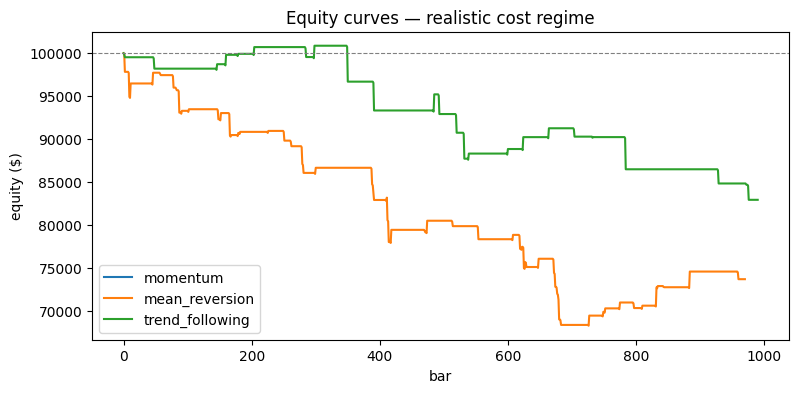

In [6]:
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 4))
    for run in [r for r in outcome.runs if r.cost_regime == "realistic"]:
        eq = run.result.equity_curve
        ax.plot(range(len(eq)), eq.to_numpy(), label=run.strategy)
    ax.axhline(100_000, color="grey", lw=0.8, ls="--")
    ax.set_title("Equity curves — realistic cost regime")
    ax.set_xlabel("bar"); ax.set_ylabel("equity ($)"); ax.legend()
    plt.show()
except ImportError:
    print("[plots skipped] install the viz group: uv sync --group viz")

Drawdown of the worst-affected run (the most informative view):

mean_reversion/high: min drawdown = -0.5074


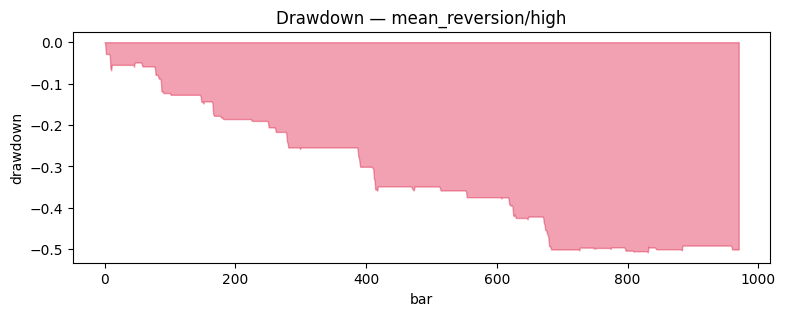

In [7]:
worst_dd = min(outcome.runs, key=lambda r: r.result.max_drawdown)
dd = drawdown_series(worst_dd.result.equity_curve)
dd_min = dd.min()
print(f"{worst_dd.strategy}/{worst_dd.cost_regime}: min drawdown = {round(float(dd_min), 4) if dd_min is not None else float('nan')}")
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.fill_between(range(len(dd)), dd.to_numpy(), 0, color="crimson", alpha=0.4)
    ax.set_title(f"Drawdown — {worst_dd.strategy}/{worst_dd.cost_regime}")
    ax.set_xlabel("bar"); ax.set_ylabel("drawdown")
    plt.show()
except ImportError:
    print("[plots skipped] install the viz group: uv sync --group viz")

## §5 Findings

`write_arena_artifacts()` serialises each run's report **and** emits the three
Phase 1 `FindingCards` to `data/findings/`. We reload them from disk to prove the
round-trip — these JSON cards are the frozen contract Phase 2/3 (and the React
surface) consume verbatim.

In [8]:
cards = write_arena_artifacts(outcome)
by_id = {c.id: c for c in load_finding_cards()}
for c in cards:
    reloaded = by_id[c.id]
    print(f"[{c.axis:9s}] {c.id:18s} {c.verdict:13s} — {c.conclusion}")
    print(f"            metrics: {c.metrics}")
    assert reloaded.verdict == c.verdict  # round-trip integrity

[strategy ] strategy-comparison negative      — No strategy clears the benchmark by >0.1 Sharpe; best is momentum at 0.00 vs 1.02.
            metrics: {'momentum.sharpe': 0.0, 'mean_reversion.sharpe': -1.5925293519346782, 'trend_following.sharpe': -1.388594927318299, 'benchmark.sharpe': 1.016523613735825}
[cost     ] cost-regime        positive      — Costs barely move momentum Sharpe (0.00 -> 0.00); turnover is low.
            metrics: {'zero.sharpe': 0.0, 'realistic.sharpe': 0.0, 'high.sharpe': 0.0}
[benchmark] vs-benchmark       negative      — No strategy beats the equal-weight benchmark after realistic costs.
            metrics: {'benchmark.sharpe': 1.016523613735825, 'benchmark.total_return': 0.4613251847275106, 'momentum.sharpe': 0.0, 'momentum.total_return': 0.0, 'mean_reversion.sharpe': -1.5925293519346782, 'mean_reversion.total_return': -0.2626987757479299, 'trend_following.sharpe': -1.388594927318299, 'trend_following.total_return': -0.17042066933770894}


## §6 Caveats & next steps

- **Synthetic data.** `make demo` seeds a geometric random walk; the negative
  verdicts are the *expected* honest outcome. Re-run `equity demo seed --real`
  then re-execute §3–§5 for market-data findings.
- **Costs are point-in-time** (fee + tax); there is no slippage, borrow, or
  market-impact model.
- **Momentum traded nothing** on this sample (flat equity) — itself a finding:
  the cross-sectional signal was never strong enough to cross its threshold.
- **Next (Phase 2):** leakage-free purged walk-forward CV, an XGBoost vs LightGBM
  comparison, and an enrichment ablation — each producing its own `FindingCard`.

---
*Reproduce from the CLI:* `make demo && equity arena run --start-date 2022-01-03 --end-date 2026-08-04`